# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name:  Gamers

Created by Alvin Lee (016377491)  
Last updated: 3/6/2026  
Our dataset contains information on each game that was extracted from each of their respective store pages. The records tell us such information as the game's peak player count, review count, Metacritic scores, and user reviews based on recommendation.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls '.'

drive  sample_data


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./drive/MyDrive/games_march2025_cleaned.csv', engine='python', on_bad_lines='skip')

In [5]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


### Q1: Show the number of missing data in each column of the dataframe

In [ ]:
# Your code here . . .
df.isnull().sum()

,0
appid,0
name,0
release_date,0
required_age,0
price,0
dlc_count,0
detailed_description,197
about_the_game,220
short_description,120
reviews,79217


### Q2: Show the data type for each column of the dataframe

In [ ]:
# Your code here . . .
df.dtypes

,0
appid,int64
name,object
release_date,object
required_age,int64
price,float64
dlc_count,int64
detailed_description,object
about_the_game,object
short_description,object
reviews,object


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

In [ ]:
# Your code here . . .
df['positive_ratio'] = df['positive'] / (df['positive'] + df['negative'])
df['metacritic_score'] = df['metacritic_score'].replace(0, np.nan)


Text(0.5, 1.05, 'Relationship between Steam Player Reviews, Critic Reviews, Player Recommendations, and Popularity')

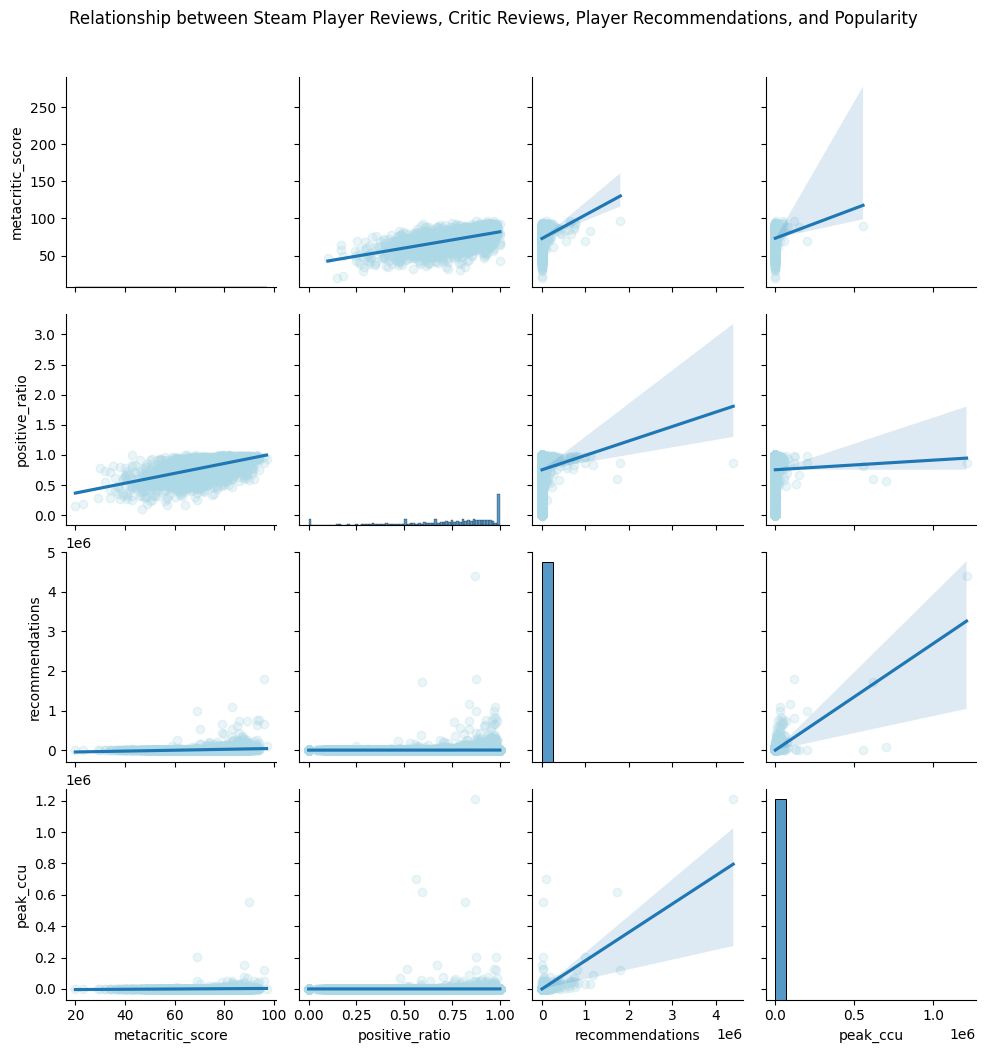

In [ ]:
sns.pairplot(data=df,
             vars=['metacritic_score', 'positive_ratio', 'recommendations', 'peak_ccu'],
             kind='reg',
             plot_kws={"scatter_kws": {"alpha":0.25, "color":"lightblue"}})
plt.suptitle("Relationship between Steam Player Reviews, Critic Reviews, Player Recommendations, and Popularity", y=1.05)

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

Text(0.5, 1.0, 'Price vs User Score')

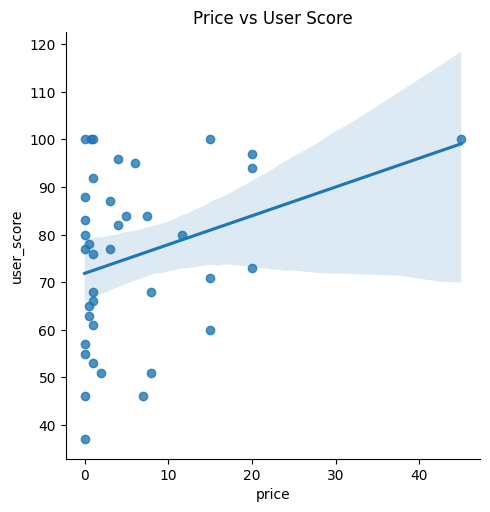

In [10]:
# Your code here . . .
sns.lmplot( data=df[df['user_score'] > 0],
            x="price",
            y="user_score",
            ci=95
)

plt.title("Price vs User Score")

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

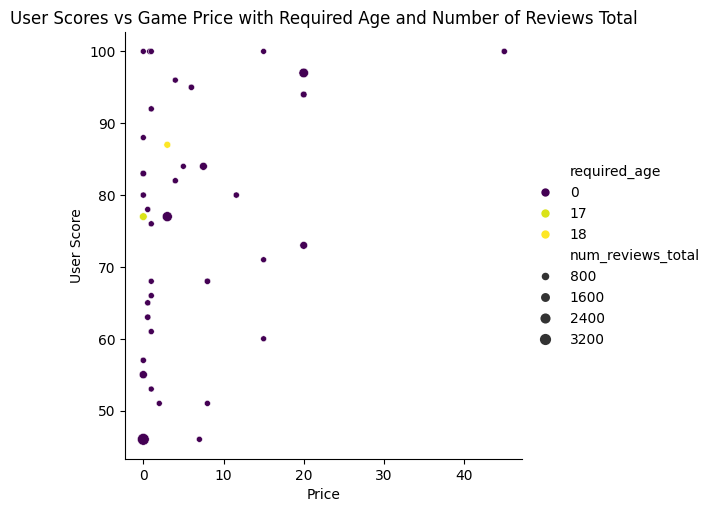

In [ ]:
# Your code here . . . -ronald
sns.relplot(
    data=df[df['user_score']>0],
    x="price",
    y="user_score",
    hue="required_age",
    size="num_reviews_total",
    kind="scatter",
    palette="viridis"
)

plt.title("User Scores vs Game Price with Required Age and Number of Reviews Total")
plt.xlabel("Price")
plt.ylabel("User Score")
plt.show()


### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

In [ ]:
# Your code here . . .
# By Alvin Lee

import ast

max_tags = df['tags'].apply(lambda x: ast.literal_eval(x))

In [ ]:
max_tags = max_tags.apply(lambda x : max(x, key=lambda t: x[t], default='NaN'))
df['max_tag'] = max_tags

In [ ]:
g = sns.relplot(
    data=df.head(1500),
    x="positive",
    y="negative",
    col="max_tag",
    col_wrap=3,
    height=5,
    s=20
)

g.set_xlabels("Positive reviews (in millions)")
g.set_ylabels("Negative reviews (in millions)")
g.fig.suptitle("User Reviews Based on the Most Popular Tag", x=0.5, y=1.05)

Text(0.5, 1.05, 'User Reviews Based on the Most Popular Tag')